# Main MW analysis

This code extracts metachronal wave parameters from timelapses of spinning Didinium cells. 
Timelapses have to be registered in advance. 

Summary of approach: 

After correction of uneven illumination and normalization, points along the cell perimeter are manually selected and a circle is fitted to detect the cell body. 
Using the circle parameters, the timelapse is masked using a ring-shaped mask of height equal to the ciliary length. The segment is then converted to polar coordinates. 
By averaging within a thin slice along the ciliary band a kymograph is generated and the 2D autocorrelation is calculated using the Wiener–Khinchin theorem.
The cilia beat frequency and the wavelength of the pattern is then detected from the power spectral densities (PSD).
The velocity of the wave is measured using the Alignment by Fourier Transform (AFT) method that was adapted from Marcotti S. et al., Frontiers in Computer Science, 2021 (https://doi.org/10.3389/fcomp.2021.745831)


**Input:**
- Paths

*file_directory* : The path to the directory containing the tif file to be analyzed. An output folder will be created in the same location.

*file_name*      : The name of the tif file of the spinning Didinium after regisytration. 

*input_parameters_path* : A csv with the parameters to be used. The parameters are explained in the Input section


**Output:**

*output_results.csv*: A csv file with all measured parameters and the corresponding errors.

*parameters.csv*:  The parameters that were used to run the code. 

The dataframes corresponding to the kymograph and the correlation are additionally saved as .pkl files. 


In [4]:
import os
import tifffile
import pandas as pd

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import interpolate, signal
from skimage import filters, measure
from skimage.morphology import disk 
import numpy.matlib as matlib
import scipy.ndimage as ndimage

import polarTransform
from tqdm import tqdm

from functions import *

### Input

In [ ]:
### Path to folder of registered MW timelapse and name of the tiff file to be processed
file_directory = "C:\\Users\\kourkoul\\SCRIPTS\\Paper_scripts\\example_data\\"
file_name = "cell_01_registered_step10.tif"

### Reading the parameters file
input_parameters_path = file_directory + "parameters.csv"
input_parameters = pd.read_csv(input_parameters_path)

### Pixel size and framerate of timelapse:
pixel_size = input_parameters["pixel_size"][0]  # μm 
fps        = input_parameters["fps"][0]         # frame rate

# Parameters preparing data for masking before the polar transform
mask_ring_range  = input_parameters["mask_ring_range"][0]       # μm    (width of the ring mask that isolates the ciliary band)
displace_inwards = input_parameters["displace_inwards"][0]      # pixel (positive number corresponds to inwards displacement of the mask to make sure the whole cilia length is included)
threshold_isolate = input_parameters["threshold_isolate"][0]    # assistive parameter to isolate only the region of interest after the polar transform

### After obtaining a polar transform, a kymograph tracing cilia activity is generated.
### To have a one-dimensional representation of ciliary activity for the kymograph, we average vertically over a slice of 3 μm height centered at the middle of the ciliary bands
### The following parameter determines the position of the slice: [[low_border, high_border]]
### where low_border is the distance from the cell surface and [high_border - low_border] determines the width of the slice
x_new_low  = input_parameters["x_new_low"][0]    # μm   (distance from the cell surface)
x_new_high = input_parameters["x_new_high"][0]   # μm   ([high_border - low_border] determines the width of the slice)

x_new_band_borders_options = [[x_new_low,x_new_high]] # μm (the slice range)

### For the velocity calculation:
num_windows      = input_parameters["num_windows"][0]        # Number of windows. Recommended : equal to number of pattern repeats along time in the autocorrelation +/- 1
sigma_velocity   = input_parameters["sigma_velocity"][0]     # Used for gaussian blurring to facilitate the detection of the slope.  Recommended: <= 5
overlap_velocity = input_parameters["overlap_velocity"][0]   # Overlap of windows (if it's equal to 1, there is no overlap).

### Pre-processing

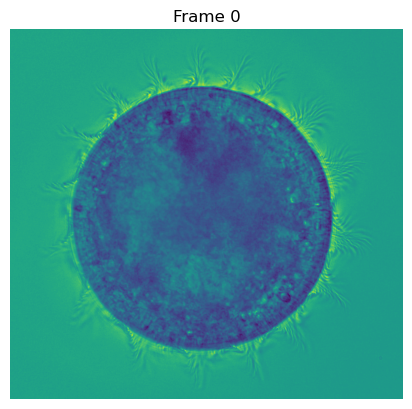

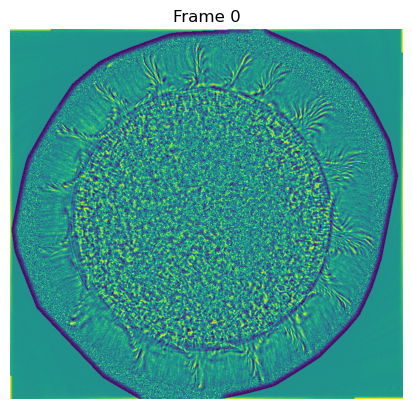

In [6]:
### Sets file path and makes output folder
file_path = file_directory + "\\" + file_name
output_path = file_directory + "\\output_MW\\" 

if not os.path.exists(output_path):
    os.makedirs(output_path)
    
### Reading file info and visual inspection
image, frame_width, frame_height, num_frames = open_tif(file_path)

frame_index = 0
show_frame_no_axes(image,frame_index)

### Signal normalization
image_illum_fix = uneven_illumination_fix(image, 31)
image_norm = img_norm_simple(image_illum_fix)

show_frame_no_axes(image_norm,frame_index)


### Cell detection and mask generation

In [7]:
%matplotlib qt  

### Frame to use for cell body detection:
frame_index = 0
    
### Manually select points along the perimeter of the cell and press 'space' to save them
image_preview = image[frame_index,:,:]
output_perimeter_file = output_path + "selected_points.csv"

select_points_perimeter_and_save(image_preview, output_perimeter_file)


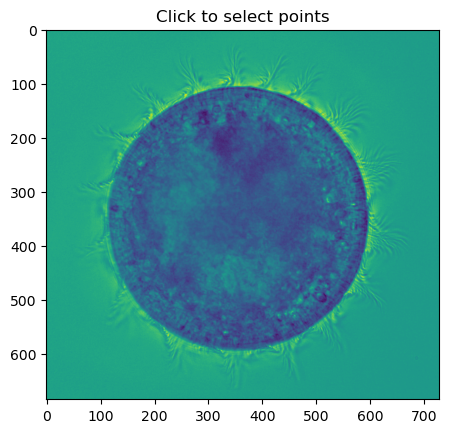

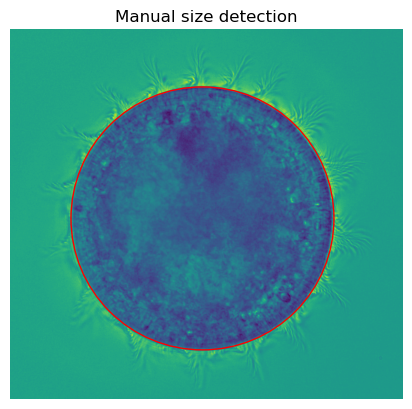

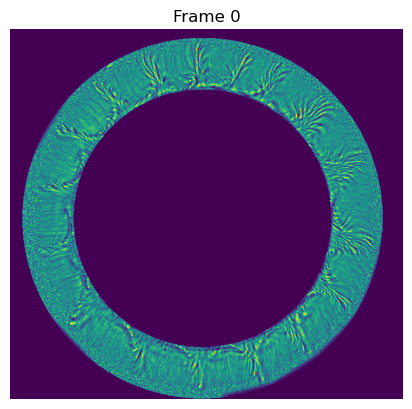

In [8]:
%matplotlib inline
### Cell body detection
manual_perimeter = read_manual_perimeter_to_array(output_perimeter_file)
x_c, y_c, r_c = fit_circle(manual_perimeter)
plot_detected_circle_from_manual_points(image_preview, x_c, y_c, r_c, output_path)
save_size_csv(output_path+"size.csv", x_c, y_c, r_c)

### ROI selection

### Create a ring-shaped mask isolating the array. The mask should include the whole cilia length
mask_width = int(mask_ring_range / pixel_size)

### Displace the mask slightly towards the cell center to make sure the base of the cilia is not cropped
r_in  = r_c - displace_inwards
r_out = r_c + (mask_width - displace_inwards)
mask = mask_ring(image, x_c, y_c, r_in, r_out)

### Apply the mask
masked_image = image_norm * mask
show_frame_no_axes(masked_image, frame_index = 0)


In [9]:
### Polar transform
### This step might take a few minutes depending on the resolution and duration of the timelapse
polar_trans_image = polar_transform(masked_image, x_c, y_c, r_c)

### Save the polar transform:
tifffile.imwrite(output_path +"polar_transform.tif", polar_trans_image)

100%|██████████| 502/502 [00:34<00:00, 14.68it/s]


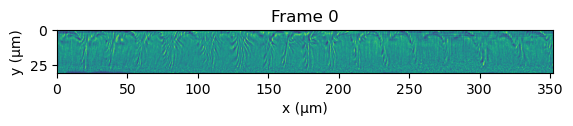

In [10]:
### Isolate ROI in the new representation
isolate_assistant = polar_trans_image[10,:,10]
# Find the indices where the sum is non-zero
non_zero_indices = np.where(isolate_assistant >= threshold_isolate)[0]
### Get the borders:
y1 = non_zero_indices[0]
y2 = non_zero_indices[-1] + 1  

kymograph_prep = polar_trans_image[:,y1:y2,:]
show_frame_in_microns(kymograph_prep, 0, pixel_size)

### Save the unwrapped ciliary band:
tifffile.imwrite(output_path +"kymograph_prep.tif", kymograph_prep)

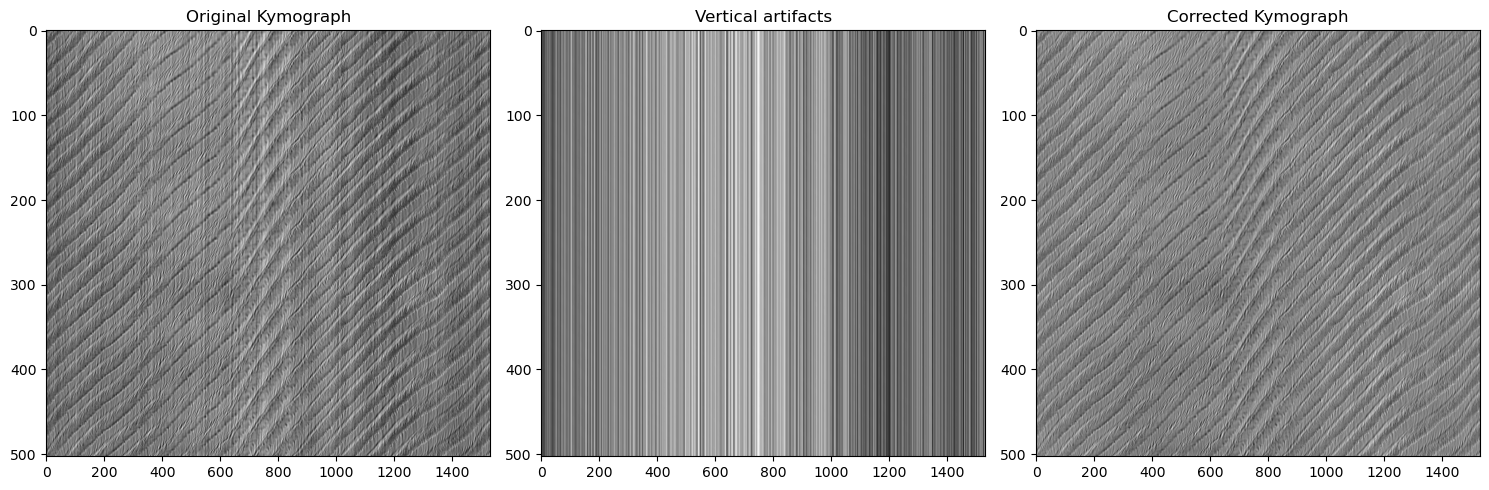

c:\Users\kourkoul\AppData\Local\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:84: FutureWarning: In a future version, DataFrame.min(axis=None) will return a scalar min over the entire DataFrame. To retain the old behavior, use 'frame.min(axis=0)' or just 'frame.min()'
  return reduction(axis=axis, out=out, **passkwargs)
c:\Users\kourkoul\AppData\Local\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:84: FutureWarning: In a future version, DataFrame.max(axis=None) will return a scalar max over the entire DataFrame. To retain the old behavior, use 'frame.max(axis=0)' or just 'frame.max()'
  return reduction(axis=axis, out=out, **passkwargs)


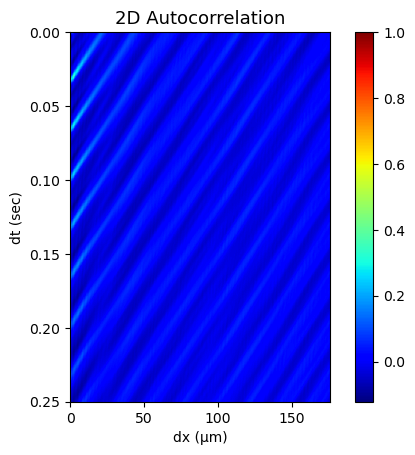

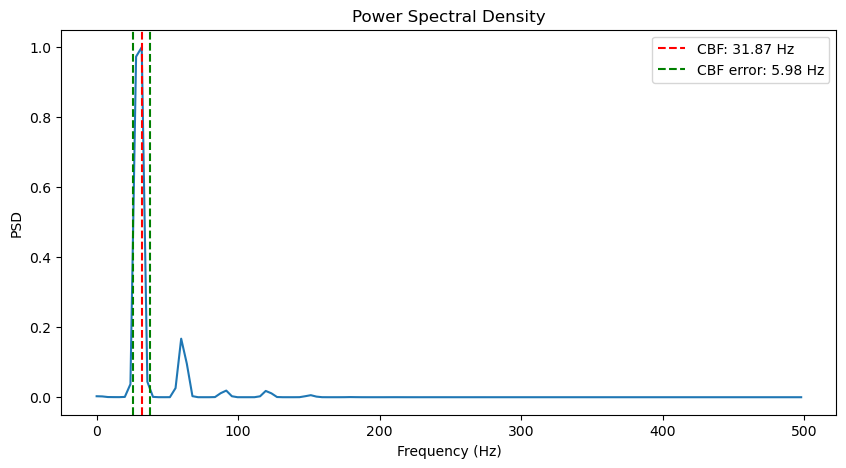

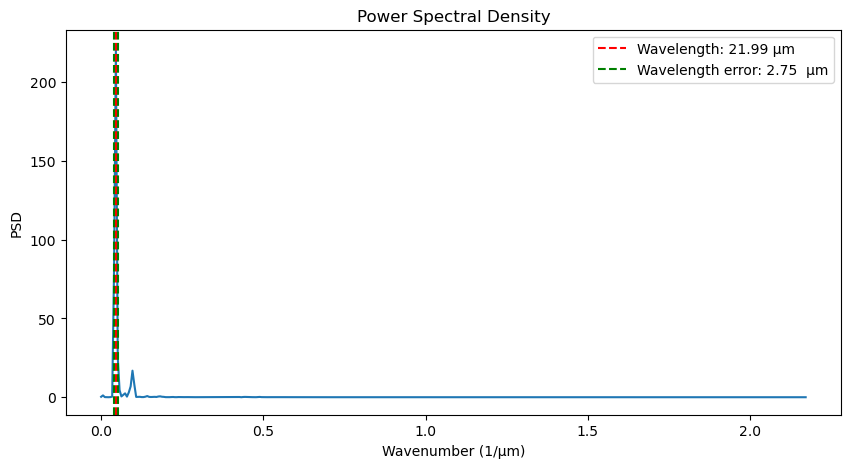

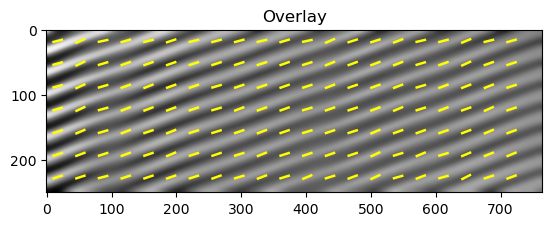

velocity (μm/sec)          :  666.3860265286253
error in velocity (μm/sec) :  104.31125042240504


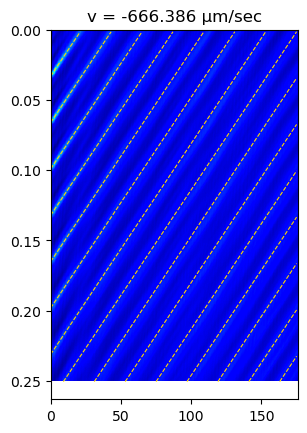

In [ ]:
### Creates a 1D representation of the band at a given height, prepares a kymograph and calculates the 2d autocorrelation and the MW parameters.
for x_new_band_borders in x_new_band_borders_options:
    # Optionally, measurements can be done for multiple heights from the surface. For each choice a subfolder is created for the coresponding output.
    output_path = file_directory + "\\output_MW\\slices\\"+str(x_new_band_borders[0]) + "_to_" + str(x_new_band_borders[1]) +"_microns\\"  
    if not os.path.exists(output_path):
        os.makedirs(output_path)
    
    ### Creating an 1D representation of ciliary array for the calculation of the kymograph by averaging within each column of the slice
    start_index = int(x_new_band_borders[0]/pixel_size)
    end_index = int(x_new_band_borders[1]/pixel_size)
    x_new = np.mean(kymograph_prep[:, start_index:end_index, :], axis=1)
        
    num_pixels = x_new.shape[1]
    
    ### Convert 'x_new' to a dataframe with the average column intensity in time : 'c_intensity'
    c_intensity = pd.DataFrame(index = pd.Index(np.arange(num_frames)), columns = pd.Index(range(num_pixels)))
    c_intensity.index.name = 'Time (frames)'
    c_intensity.columns.name = 'Position along the cilia (pixel)'

    for i in range(num_pixels):
        c_intensity[i] = x_new[:,i]
            
    ### To plot the kymograph rescaled in μm and sec
    num_frames = c_intensity.index.max() + 1
    num_pixels = c_intensity.columns.max() + 1
    
    new_index = pd.Index(np.arange(num_frames) / fps)
    new_columns = pd.Index(np.arange(num_pixels) * pixel_size)
    
    ### Adjust the indices of the dataframe
    rescaled_c_intensity = c_intensity.copy()
    rescaled_c_intensity.index = new_index
    rescaled_c_intensity.columns = new_columns
    rescaled_c_intensity.index.name = 'time (sec)'
    rescaled_c_intensity.columns.name = 'position along the cilia (\u03BCm)'
    
    ### Save rescaled_c_intensity
    rescaled_c_intensity.to_pickle(output_path + "rescaled_c_intensity.pkl")

    ### Correct for vertical illumination artifacts
    kymograph = c_intensity
    filter_size = 1000
    corrected_kymograph = vertical_artifacts_correction(kymograph, filter_size, output_path)
    
    ### Calculate the 2D autocorrelation
    c = autocorrelation2D_fft_units(corrected_kymograph)
    index_t = np.arange(c.shape[0])
    index_x = np.arange(c.shape[1])
    ### Turning c to dataframe:
    correlation = pd.DataFrame(data = c, index = pd.Index(index_t/fps), columns = pd.Index(index_x*pixel_size)) 
    correlation.index.name = 'dt (sec)'
    correlation.columns.name = 'dx (\u03BCm)'
    
    ### Visualization of autocorrelation: 
    autocorrelation2D_visualization_units(correlation)
    plt.savefig(output_path + "autocorrelation.png", dpi=300)
    ### Save autocorrelation:
    correlation.to_pickle(output_path + "correlation.pkl")
    
    ### Calculating parameters of interest--------------------------------------------
    
    ### CBF by averaging over all space lags:
    temporal_sampling_freq = fps
    frequencies, psd_t_norm, std_frequencies, std_psd_t, CBF, CBF_error = output_CBF_average(correlation, temporal_sampling_freq)
   
    ### Plotting of PSD with CBF:
    plot_CBF(frequencies, psd_t_norm, std_psd_t, CBF, CBF_error)
  
    ### λ by averaging over all space lags:
    spatial_sampling_freq = 1/pixel_size  # pixel/μm 
    average_wavenumbers, average_psd_x, std_wavenumbers, std_psd_x, wavelength, wavelength_error, primary_wavenumber, wavenumber_error = output_wavelength_average(correlation, spatial_sampling_freq)
    
    ### Plotting of PSD with λ:
    plot_wavelength(average_wavenumbers, average_psd_x, std_psd_x, primary_wavenumber, wavenumber_error,wavelength, wavelength_error)

    ### Calculating velocity using AFT:
    velocity, velocity_error = velocity_by_aft(correlation, pixel_size, fps, num_windows, output_path, sigma = sigma_velocity,  overlap = overlap_velocity, intensity_thresh = -0.5, eccentricity_thresh = 0, visualize_results = True)
    
    ### Visualizes velocity of checking accuracy:
    velocity_visualization(correlation, -(velocity), fps, pixel_size, wavelength)
    plt.savefig(output_path + "velocity_check.png", dpi=300)
    
    ### Save parameters to csv:
    headers_param = ['file_name','pixel_size', 'fps', 'mask_ring_range', 'displace_inwards', 'threshold_isolate', 'num_windows', 'sigma_velocity', 'overlap_velocity']
    data_parameters = [file_name, pixel_size, fps, mask_ring_range, displace_inwards, threshold_isolate, num_windows, sigma_velocity, overlap_velocity]
    save_csv_file(output_path+'parameters.csv', headers_param, data_parameters)
    
    ## Save results to csv:
    headers = ['file_name', 'pixel_size (microns)', 'fps', 'radius (microns)', 'CBF (Hz)', 'CBF_error (Hz)', 'wavelength (microns)', 'wavelength_error (microns)', 'velocity (microns/sec)', 'velocity_error (microns/sec)']
    data = [file_name, pixel_size, fps, r_c*pixel_size, CBF, CBF_error, wavelength, wavelength_error, velocity, velocity_error]
    save_csv_file(output_path + 'output_results.csv', headers, data)
    